# Support Vector Machines

This notebook introduces Support Vector Machine classifiers with the Breast Cancer Wisconsin Diagnostic dataset from `scikit-learn`.

Dataset: Breast Cancer Wisconsin Diagnostic dataset. We predict whether a tumor is **malignant** (`1`) or **benign** (`0`).

The main focus is the regularization parameter `C`:

- small `C`: stronger regularization, wider margin, more tolerance for training errors;
- large `C`: weaker regularization, narrower margin, stronger pressure to classify the training set correctly;
- very large `C` can produce a more complex or brittle decision boundary, especially with flexible kernels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (8, 4.5),
})

## 1. Load the Breast Cancer Dataset

`load_breast_cancer` is bundled with `scikit-learn`, so the notebook does not need external data files.

The original target uses `0 = malignant` and `1 = benign`. For consistency with earlier classification notebooks, we recode it so that:

- `1` means **malignant**, the positive class;
- `0` means **benign**.

In [2]:
cancer = load_breast_cancer(as_frame=True)
raw_df: pd.DataFrame = cancer.frame.copy()

X = raw_df.drop(columns="target")
y = (raw_df["target"] == 0).astype(int)

label_names = {0: "benign", 1: "malignant"}
display_labels = [label_names[0], label_names[1]]

preview_df = X.copy()
preview_df["diagnosis"] = y.map(label_names)

class_balance = pd.DataFrame({
    "label": pd.Series(label_names),
    "count": y.value_counts().sort_index(),
    "share": y.value_counts(normalize=True).sort_index(),
})

print(f"Rows: {len(raw_df)}")
print(f"Features: {X.shape[1]}")
print(f"Original sklearn target names: {list(cancer.target_names)}")

display(class_balance)
preview_df.head()

Rows: 569
Features: 30
Original sklearn target names: ['malignant', 'benign']


,label,count,share
0,benign,357,0.6274
1,malignant,212,0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,malignant
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,malignant
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,malignant
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,malignant
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,malignant


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "malignant_share": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

split_summary

,rows,malignant_share
train,426,0.3732
test,143,0.3706


## 2. Why Scaling Matters for SVMs

SVMs use distances and margins. If one feature is measured on a much larger numeric scale than another, it can dominate the learned boundary.

For that reason, the examples below use a pipeline:

1. standardize every feature with `StandardScaler`;
2. fit an `SVC` model on the scaled features.

The pipeline prevents data leakage because scaling parameters are learned only from the training folds during cross-validation.

## 3. Compare Different Values of `C`

First, we use all 30 features and a linear SVM. A linear SVM makes it easy to connect `C` to the margin:

- the learned weight vector is `w`;
- the margin width is proportional to `2 / ||w||`;
- larger `C` usually increases `||w||`, which narrows the margin.

The number of support vectors is also useful. Support vectors are the training examples that define the boundary or violate the margin.

In [4]:
C_values = [0.01, 0.1, 1, 10, 100]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

rows = []

for C in C_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C),
    )

    cv_scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    svc = model.named_steps["svc"]
    coef_norm = np.linalg.norm(svc.coef_)

    rows.append({
        "C": C,
        "cv_accuracy_mean": cv_scores["test_accuracy"].mean(),
        "cv_f1_mean": cv_scores["test_f1"].mean(),
        "cv_roc_auc_mean": cv_scores["test_roc_auc"].mean(),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_f1": f1_score(y_train, train_pred),
        "test_f1": f1_score(y_test, test_pred),
        "support_vectors": int(svc.n_support_.sum()),
        "margin_width": 2 / coef_norm,
    })

svm_results = pd.DataFrame(rows)
svm_results

,C,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,train_accuracy,test_accuracy,train_f1,test_f1,support_vectors,margin_width
0,0.01,0.9647,0.9500,0.9899,0.9671,0.9580,0.9542,0.9400,101,2.9064
1,0.10,0.9671,0.9547,0.9932,0.9836,0.9790,0.9776,0.9709,51,1.4204
2,1.00,0.9694,0.9581,0.9889,0.9906,0.9580,0.9873,0.9400,36,0.7378
3,10.00,0.9600,0.9457,0.9838,0.9930,0.9580,0.9905,0.9412,28,0.2507
4,100.00,0.9553,0.9397,0.9816,1.0000,0.9301,1.0000,0.9000,24,0.0798


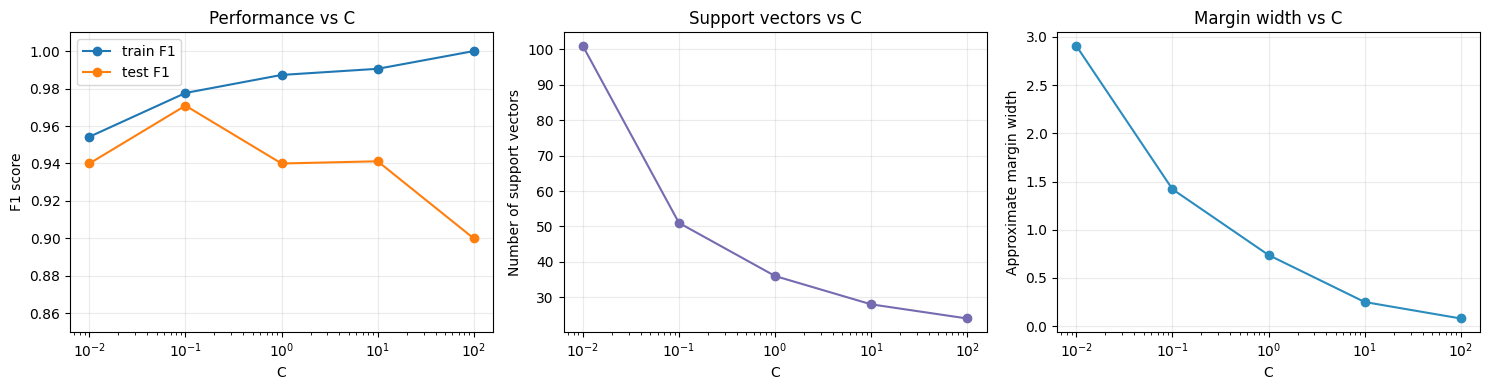

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(svm_results["C"], svm_results["train_f1"], marker="o", label="train F1")
axes[0].semilogx(svm_results["C"], svm_results["test_f1"], marker="o", label="test F1")
axes[0].set_title("Performance vs C")
axes[0].set_xlabel("C")
axes[0].set_ylabel("F1 score")
axes[0].set_ylim(0.85, 1.01)
axes[0].legend()

axes[1].semilogx(svm_results["C"], svm_results["support_vectors"], marker="o", color="#756bb1")
axes[1].set_title("Support vectors vs C")
axes[1].set_xlabel("C")
axes[1].set_ylabel("Number of support vectors")

axes[2].semilogx(svm_results["C"], svm_results["margin_width"], marker="o", color="#2b8cbe")
axes[2].set_title("Margin width vs C")
axes[2].set_xlabel("C")
axes[2].set_ylabel("Approximate margin width")

plt.tight_layout()
plt.show()

A small `C` creates a wider margin and usually leaves more points as support vectors. A large `C` penalizes margin violations more heavily, so the model tries harder to separate the training data.

The best test score is not always at the largest `C`. When training performance keeps improving but test performance stops improving or gets worse, the model is starting to overfit.

Best C by test F1 in this split: 0.1
              precision    recall  f1-score   support

      benign       0.97      1.00      0.98        90
   malignant       1.00      0.94      0.97        53

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



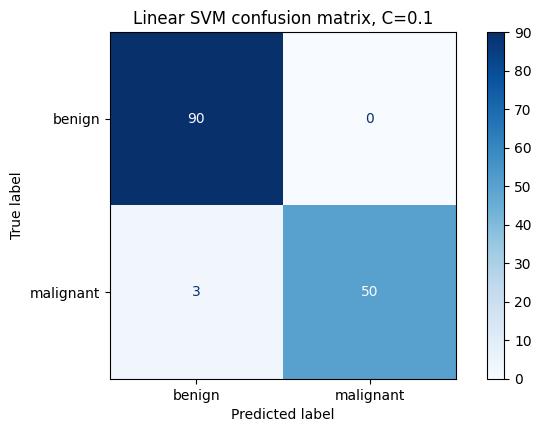

In [6]:
best_row = svm_results.sort_values(
    ["test_f1", "test_accuracy", "cv_f1_mean"],
    ascending=False,
).iloc[0]

best_C = best_row["C"]
best_linear_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=best_C),
)
best_linear_svm.fit(X_train, y_train)

best_test_pred = best_linear_svm.predict(X_test)

print(f"Best C by test F1 in this split: {best_C}")
print(classification_report(y_test, best_test_pred, target_names=display_labels))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_test_pred,
    display_labels=display_labels,
    cmap="Blues",
)
plt.title(f"Linear SVM confusion matrix, C={best_C}")
plt.grid(False)
plt.show()

## 4. Visualize Learned Decision Areas

The full model uses 30 features, so its boundary cannot be plotted directly. To see the learned SVM areas, we fit separate SVMs on two informative features:

- `mean concave points`
- `worst radius`

These 2D models are for visualization. They usually perform worse than the full 30-feature model, but they make the margin, boundary, and support vectors visible.

In [7]:
two_features = ["mean concave points", "worst radius"]
X_train_2d = X_train[two_features]
X_test_2d = X_test[two_features]

class_cmap = ListedColormap(["#2ca25f", "#de2d26"])
region_cmap = ListedColormap(["#c7e9c0", "#fcbba1"])


def make_grid(X_2d, grid_size=250):
    x_min, x_max = X_2d.iloc[:, 0].min(), X_2d.iloc[:, 0].max()
    y_min, y_max = X_2d.iloc[:, 1].min(), X_2d.iloc[:, 1].max()

    x_padding = (x_max - x_min) * 0.08
    y_padding = (y_max - y_min) * 0.08

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_padding, x_max + x_padding, grid_size),
        np.linspace(y_min - y_padding, y_max + y_padding, grid_size),
    )
    grid = pd.DataFrame({
        two_features[0]: xx.ravel(),
        two_features[1]: yy.ravel(),
    })
    return xx, yy, grid


def plot_svm_regions(kernel, C_values_to_plot, gamma="scale"):
    xx, yy, grid = make_grid(X_train_2d)
    fig, axes = plt.subplots(1, len(C_values_to_plot), figsize=(4.5 * len(C_values_to_plot), 4), sharex=True, sharey=True)

    if len(C_values_to_plot) == 1:
        axes = [axes]

    for ax, C in zip(axes, C_values_to_plot):
        model = make_pipeline(
            StandardScaler(),
            SVC(kernel=kernel, C=C, gamma=gamma),
        )
        model.fit(X_train_2d, y_train)

        region = model.predict(grid).reshape(xx.shape)
        decision_values = model.decision_function(grid).reshape(xx.shape)

        scaler = model.named_steps["standardscaler"]
        svc = model.named_steps["svc"]
        support_vectors = scaler.inverse_transform(svc.support_vectors_)

        ax.contourf(xx, yy, region, cmap=region_cmap, alpha=0.65)
        ax.contour(xx, yy, decision_values, levels=[0], colors="black", linewidths=2)

        scatter = ax.scatter(
            X_train_2d.iloc[:, 0],
            X_train_2d.iloc[:, 1],
            c=y_train,
            cmap=class_cmap,
            edgecolor="white",
            linewidth=0.5,
            s=36,
            alpha=0.9,
        )
        ax.scatter(
            support_vectors[:, 0],
            support_vectors[:, 1],
            s=85,
            facecolors="none",
            edgecolors="black",
            linewidths=1.2,
            label="support vectors",
        )

        ax.set_title(f"C={C}\nsupport vectors={svc.n_support_.sum()}")
        ax.set_xlabel(two_features[0])
        ax.set_ylabel(two_features[1])

    handles, _ = scatter.legend_elements()
    labels = [label_names[0], label_names[1]]
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.suptitle(f"{kernel.upper()} SVM decision areas as C changes", y=1.08)
    plt.tight_layout()
    plt.show()

### Linear Kernel

With a linear kernel, the decision boundary is a straight line in this two-feature space. Increasing `C` changes how strongly the model reacts to difficult points near or across the boundary.

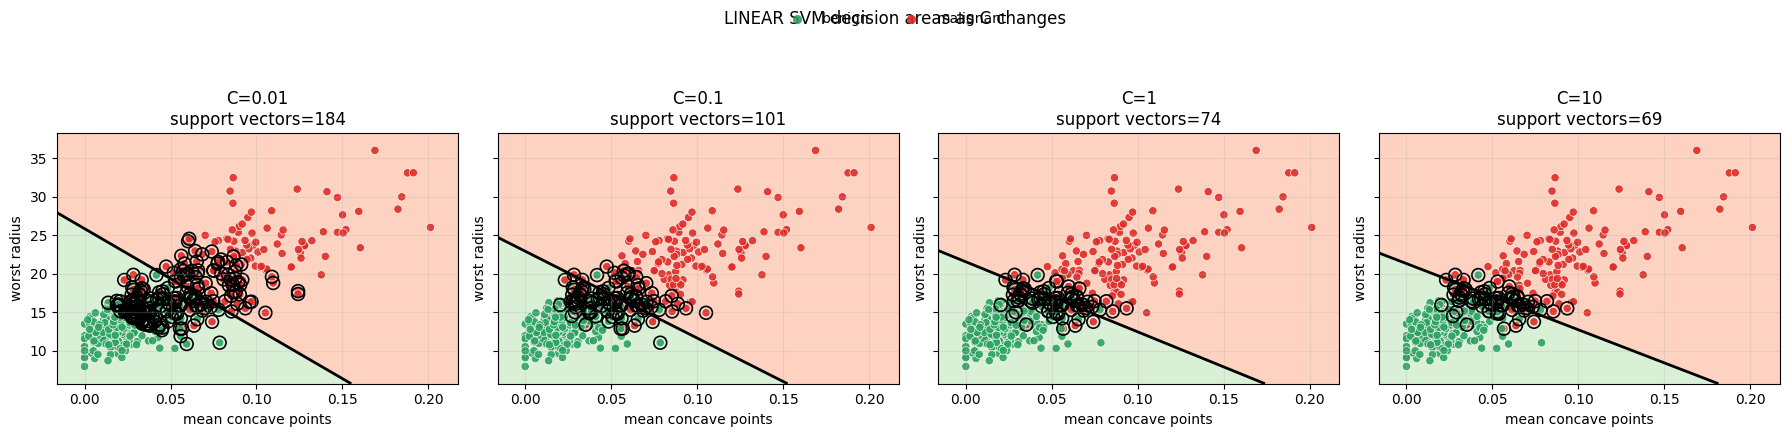

In [8]:
plot_svm_regions(kernel="linear", C_values_to_plot=[0.01, 0.1, 1, 10])

### RBF Kernel

With an RBF kernel, the SVM can learn curved decision boundaries. This makes the impact of `C` easier to see:

- low `C`: smoother boundary, more tolerance for mistakes;
- high `C`: boundary bends more to classify training examples correctly.

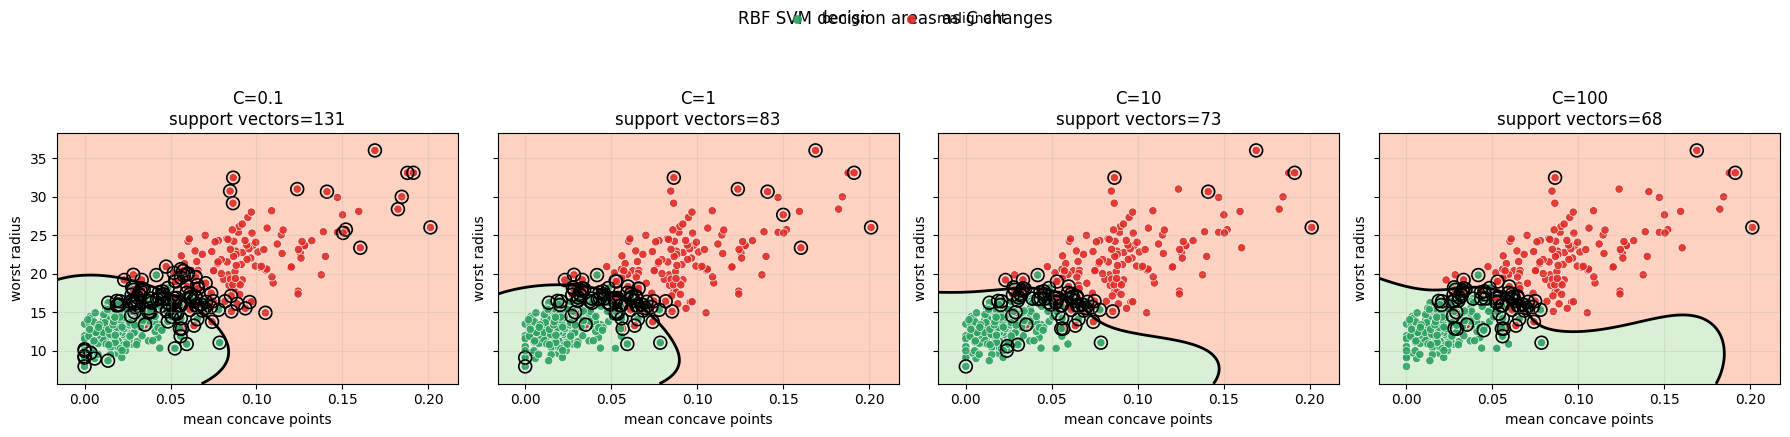

In [9]:
plot_svm_regions(kernel="rbf", C_values_to_plot=[0.1, 1, 10, 100])

## 5. Two-Feature RBF Model: Overfitting Check

The plots show the shape of the boundary. The table and chart below show whether that shape helps generalization.

A useful warning sign is a widening train/test gap: training accuracy rises, but test accuracy does not keep up.

,C,train_accuracy,test_accuracy,support_vectors
0,0.01,0.9178,0.8881,319
1,0.10,0.9249,0.9231,131
2,1.00,0.9296,0.9231,83
3,10.00,0.9296,0.9231,73
4,100.00,0.9319,0.9161,68


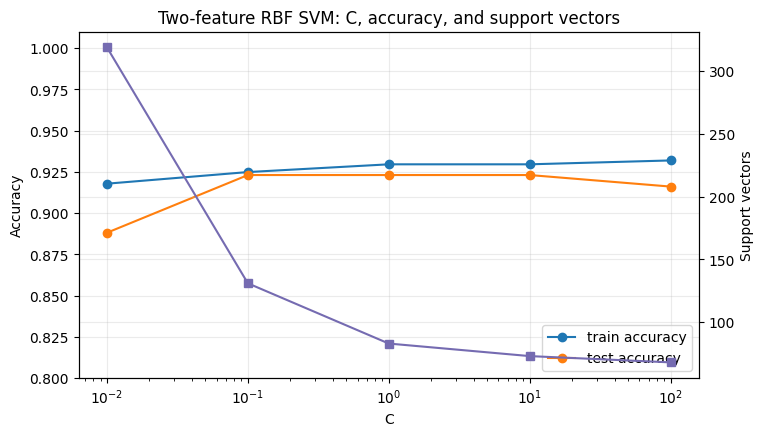

In [10]:
two_d_rows = []

for C in C_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=C, gamma="scale"),
    )
    model.fit(X_train_2d, y_train)

    svc = model.named_steps["svc"]
    two_d_rows.append({
        "C": C,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train_2d)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test_2d)),
        "support_vectors": int(svc.n_support_.sum()),
    })

two_d_results = pd.DataFrame(two_d_rows)
display(two_d_results)

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.semilogx(two_d_results["C"], two_d_results["train_accuracy"], marker="o", label="train accuracy")
ax1.semilogx(two_d_results["C"], two_d_results["test_accuracy"], marker="o", label="test accuracy")
ax1.set_xlabel("C")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0.80, 1.01)
ax1.legend(loc="lower right")

ax2 = ax1.twinx()
ax2.semilogx(two_d_results["C"], two_d_results["support_vectors"], marker="s", color="#756bb1", label="support vectors")
ax2.set_ylabel("Support vectors")

plt.title("Two-feature RBF SVM: C, accuracy, and support vectors")
plt.show()

## Key Takeaways

- SVMs learn a boundary that maximizes margin while allowing some margin violations.
- `C` controls the penalty for those violations.
- Smaller `C` values usually create wider margins and smoother boundaries.
- Larger `C` values fit the training data more aggressively and can overfit.
- Scaling is essential because SVMs depend on distances and margins.
- Decision-region plots are easiest in two dimensions, but evaluation should still use the full feature set when possible.